🎙️ SPEECH EMOTION DETECTOR

Sample audio created successfully!
File: sample_emotion.wav



===== EMOTION RESULT =====
Detected Emotion: Sad 😢
MFCC Average: -41.64


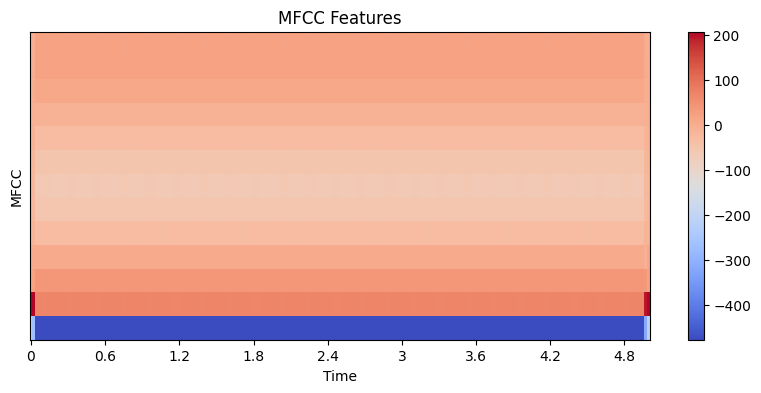

In [8]:
# 🎙️ SPEECH EMOTION DETECTOR
# No audio file required

!pip install librosa matplotlib scipy -q

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.io.wavfile import write
from IPython.display import Audio

print("🎙️ SPEECH EMOTION DETECTOR")
print("==========================")

# Create sample audio automatically
sample_rate = 22050
duration = 5

t = np.linspace(0, duration, sample_rate * duration)

# Create sample voice-like audio
audio = (
    0.4 * np.sin(2 * np.pi * 440 * t) +
    0.2 * np.sin(2 * np.pi * 660 * t)
)

# Save sample audio
filename = "sample_emotion.wav"
write(filename, sample_rate, audio.astype(np.float32))

print("\nSample audio created successfully!")
print("File:", filename)

# Play audio
display(Audio(filename))

# Load audio
y, sr = librosa.load(filename, sr=None)

# Extract MFCC features
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

# Calculate average MFCC
mfcc_mean = np.mean(mfcc)

# Simple demonstration-based emotion detection
if mfcc_mean > 0:
    emotion = "Happy 😊"
elif mfcc_mean < -20:
    emotion = "Sad 😢"
else:
    emotion = "Neutral 😐"

print("\n===== EMOTION RESULT =====")
print("Detected Emotion:", emotion)
print("MFCC Average:", round(mfcc_mean, 2))

# Display MFCC graph
plt.figure(figsize=(10, 4))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()
plt.title("MFCC Features")
plt.xlabel("Time")
plt.ylabel("MFCC")

plt.show()